In [92]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.naive_bayes import GaussianNB, MultinomialNB, CategoricalNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_curve, auc
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, classification_report

# Naive Bayes for Numerical Data

In [2]:
data = pd.read_csv('bank-full.csv', sep=';')

In [3]:
data.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


# Data Preprocessing for Numerical

In [4]:
data.isnull().sum() # Checking missing values

age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
y            0
dtype: int64

In [5]:
# Encode categorical variables
binary_columns = ['default', 'housing', 'loan', 'y']
for column in binary_columns:
    data[column] = data[column].apply(lambda x: 1 if x == 'yes' else 0)

In [6]:
# One-hot encoding for categorical columns
categorical_columns = ['job', 'marital', 'education', 'contact', 'month', 'poutcome']
for column in categorical_columns:
    one_hot = pd.get_dummies(data[column], prefix=column, drop_first=True)
    one_hot = one_hot.astype(int)  # Convert boolean to int if necessary
    data = data.drop(column, axis=1)
    data = data.join(one_hot)

In [7]:
# Normalize/Standardize numerical features
numerical_columns = ['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']
scaler = StandardScaler()
data[numerical_columns] = scaler.fit_transform(data[numerical_columns])
data.head()

,age,default,balance,housing,loan,day,duration,campaign,pdays,previous,...,month_jul,month_jun,month_mar,month_may,month_nov,month_oct,month_sep,poutcome_other,poutcome_success,poutcome_unknown
0,1.606965,0,0.256419,1,0,-1.298476,0.011016,-0.569351,-0.411453,-0.25194,...,0,0,0,1,0,0,0,0,0,1
1,0.288529,0,-0.437895,1,0,-1.298476,-0.416127,-0.569351,-0.411453,-0.25194,...,0,0,0,1,0,0,0,0,0,1
2,-0.747384,0,-0.446762,1,1,-1.298476,-0.707361,-0.569351,-0.411453,-0.25194,...,0,0,0,1,0,0,0,0,0,1
3,0.571051,0,0.047205,1,0,-1.298476,-0.645231,-0.569351,-0.411453,-0.25194,...,0,0,0,1,0,0,0,0,0,1
4,-0.747384,0,-0.447091,0,0,-1.298476,-0.233620,-0.569351,-0.411453,-0.25194,...,0,0,0,1,0,0,0,0,0,1


# Preprocessing ends

In [8]:
# Split the dataset
X = data.drop('y', axis=1)
y = data['y']

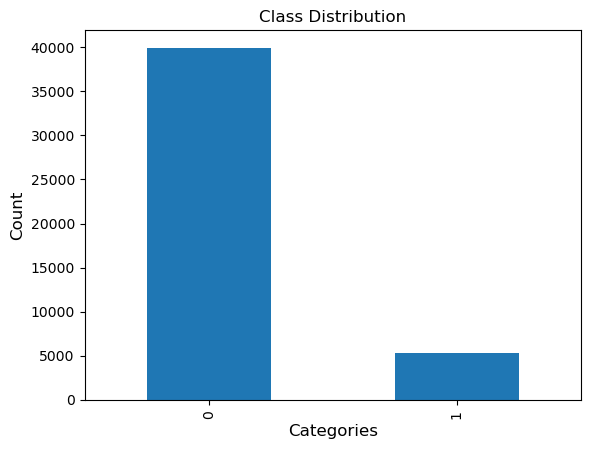

In [9]:
ax = data['y'].value_counts().plot(kind='bar')

# Adding labels
ax.set_xlabel('Categories', fontsize=12)
ax.set_ylabel('Count', fontsize=12)
ax.set_title('Class Distribution', fontsize=12)

# Displaying the plot
plt.show()


In [54]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state = 10, stratify=y)

In [55]:
from sklearn.naive_bayes import GaussianNB
gnb = GaussianNB()

In [56]:
gnb.fit(X_train, y_train)

GaussianNB()

In [57]:
y_pred_gnb = gnb.predict(X_test)

In [58]:
conf_matrix = confusion_matrix(y_test, y_pred_gnb)
print(conf_matrix)

[[10853  1124]
 [  821   766]]


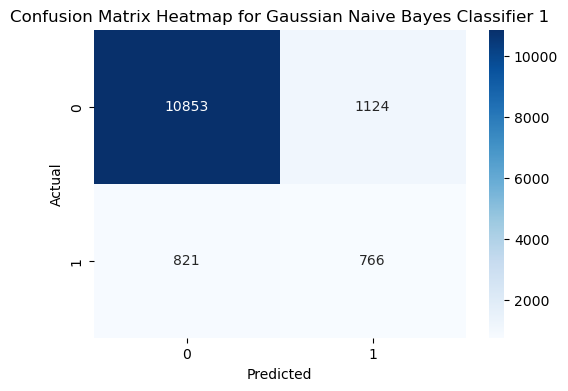

In [59]:
plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix, annot=True, cmap='Blues', fmt='d')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix Heatmap for Gaussian Naive Bayes Classifier 1')
# plt.savefig('confusion_matrix_maxdepth17.png',dpi=200)  # Save the plot as an image
plt.show()

In [60]:
from sklearn.metrics import confusion_matrix, classification_report
report = classification_report(y_test, y_pred_gnb)
print(report)

              precision    recall  f1-score   support

           0       0.93      0.91      0.92     11977
           1       0.41      0.48      0.44      1587

    accuracy                           0.86     13564
   macro avg       0.67      0.69      0.68     13564
weighted avg       0.87      0.86      0.86     13564



In [61]:
from sklearn.metrics import precision_recall_curve, roc_curve, auc

y_scores = gnb.predict_proba(X_test)
y_true = y_test

# Compute precision-recall curve
precision1, recall1, _ = precision_recall_curve(y_true, y_scores[:, 1])
# Compute precision-recall curve for class 0
precision0, recall0, _ = precision_recall_curve(y_true, y_scores[:, 0])

# Compute ROC curve for class 1
fpr1, tpr1, _ = roc_curve(y_true, y_scores[:, 1])
roc_auc1 = auc(fpr1, tpr1)
# Compute ROC curve for class 0
fpr0, tpr0, _ = roc_curve(y_true, y_scores[:, 0])
roc_auc0 = auc(fpr0, tpr0)


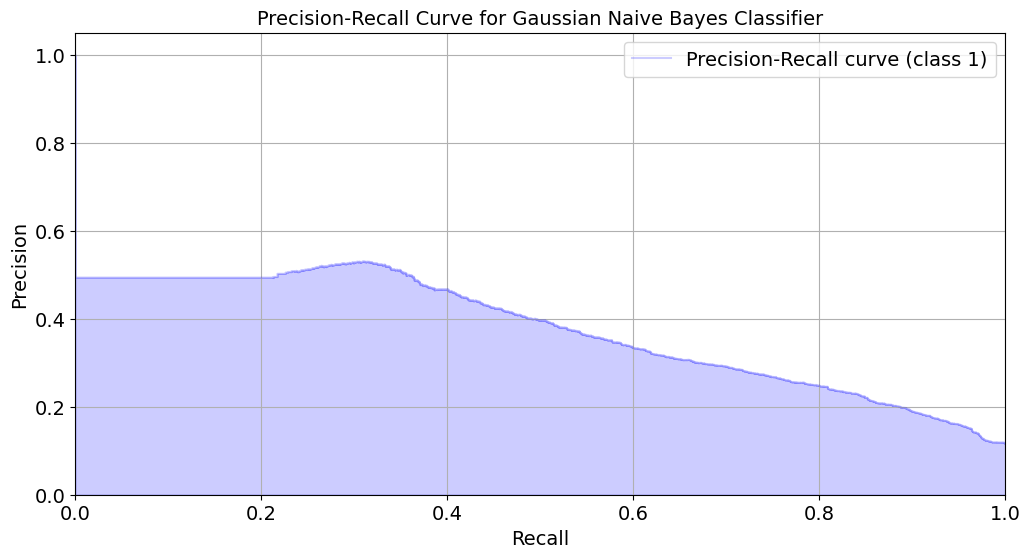

In [62]:
# Plot precision-recall curve
plt.figure(figsize=(12, 6))

plt.step(recall1, precision1, color='b', alpha=0.2, where='post', label='Precision-Recall curve (class 1)')
plt.fill_between(recall1, precision1, step='post', alpha=0.2, color='b')

plt.xlabel('Recall', fontsize=14)
plt.ylabel('Precision', fontsize=14)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.ylim([0.0, 1.05])
plt.xlim([0.0, 1.0])
plt.title('Precision-Recall Curve for Gaussian Naive Bayes Classifier', fontsize=14)
plt.grid(True)
plt.legend(loc="upper right", fontsize=14)
plt.show()

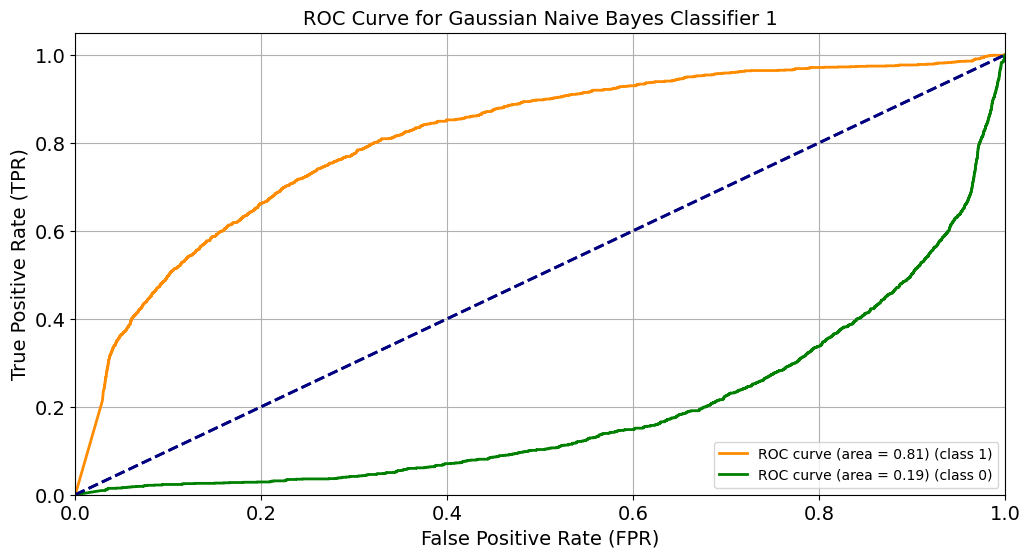

In [63]:
# Plot ROC curves
plt.figure(figsize=(12, 6))

# Plot ROC curve for class 1
plt.plot(fpr1, tpr1, color='darkorange', lw=2, label='ROC curve (area = %0.2f) (class 1)' % roc_auc1)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')

# Plot ROC curve for class 0
plt.plot(fpr0, tpr0, color='green', lw=2, label='ROC curve (area = %0.2f) (class 0)' % roc_auc0)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.xlabel('False Positive Rate (FPR)', fontsize=14)
plt.ylabel('True Positive Rate (TPR)', fontsize=14)
plt.title('ROC Curve for Gaussian Naive Bayes Classifier 1', fontsize=14)
plt.legend(loc="lower right")
plt.grid(True)

plt.show()

# Conditional Independencde:Test by Dropping Columns

In [20]:
CorrBank=data.drop("y", axis=1).apply(lambda x: x.corr(data.y))

In [27]:
# Convert to DataFrame for better visualization
correlation_df = pd.DataFrame({'Feature': CorrBank.index, 'Correlation': CorrBank.values})

# Sort the correlations by absolute value
correlation_df['AbsoluteCorrelation'] = correlation_df['Correlation'].abs()
correlation_df = correlation_df.sort_values(by='AbsoluteCorrelation', ascending=False)

print(correlation_df)

                Feature  Correlation  AbsoluteCorrelation
6              duration     0.394521             0.394521
40     poutcome_success     0.306788             0.306788
41     poutcome_unknown    -0.167051             0.167051
27      contact_unknown    -0.150935             0.150935
3               housing    -0.139173             0.139173
34            month_mar     0.129456             0.129456
37            month_oct     0.128531             0.128531
38            month_sep     0.123185             0.123185
8                 pdays     0.103621             0.103621
35            month_may    -0.102500             0.102500
9              previous     0.093236             0.093236
14          job_retired     0.079245             0.079245
17          job_student     0.076897             0.076897
29            month_dec     0.075164             0.075164
7              campaign    -0.073172             0.073172
10      job_blue-collar    -0.072083             0.072083
4             

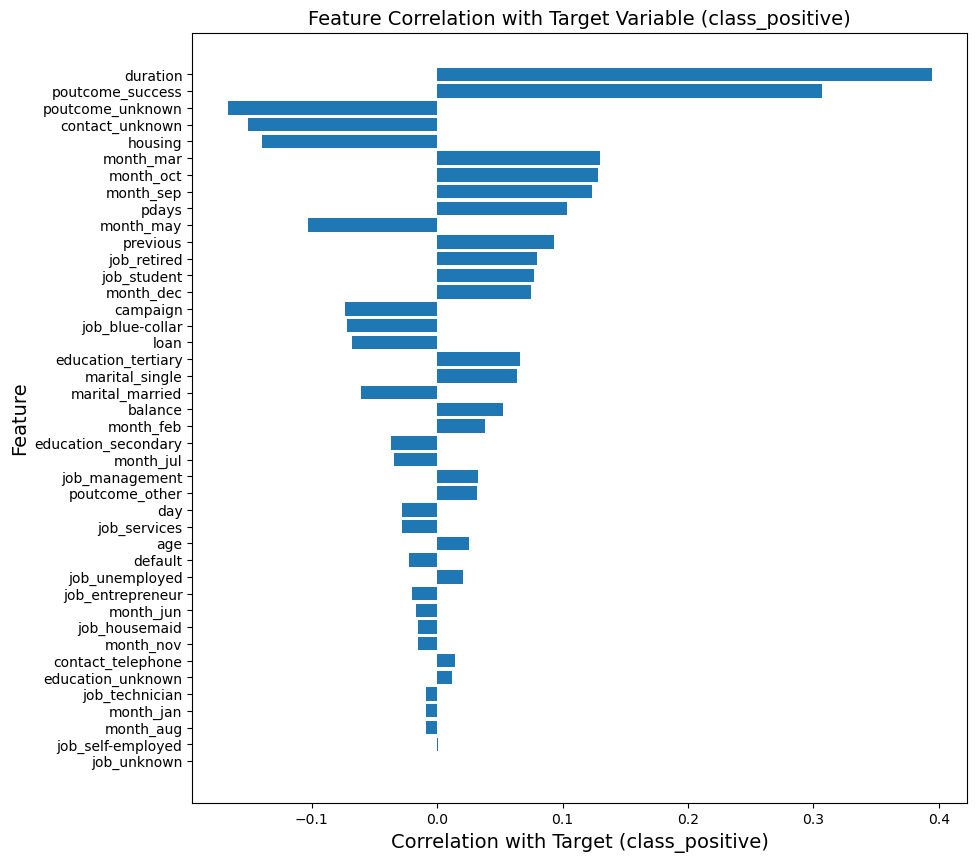

In [28]:
# Visualize the correlations
plt.figure(figsize=(10, 10))
plt.barh(correlation_df['Feature'], correlation_df['Correlation'])
plt.xlabel('Correlation with Target (class_positive)', fontsize = 14)
plt.ylabel('Feature', fontsize = 14)
plt.title('Feature Correlation with Target Variable (class_positive)', fontsize = 14)
plt.gca().invert_yaxis()
plt.show()

In [32]:
# Set a correlation threshold
threshold = 0.05

# Identify columns with correlation below threshold
low_corr_columns = correlation_df[correlation_df['AbsoluteCorrelation'] < threshold]['Feature']

# Drop columns with low correlation from the dataset
data_filtered = data.drop(low_corr_columns, axis=1)

# Print the columns being dropped
print("Columns dropped due to low correlation with 'y':\n", low_corr_columns)

# Optionally, print the remaining columns in the filtered dataset
print("Remaining columns in filtered dataset:", data_filtered.columns)

Columns dropped due to low correlation with 'y':
 30              month_feb
23    education_secondary
32              month_jul
13         job_management
39         poutcome_other
5                     day
16           job_services
0                     age
1                 default
19         job_unemployed
11       job_entrepreneur
33              month_jun
12          job_housemaid
36              month_nov
26      contact_telephone
25      education_unknown
18         job_technician
31              month_jan
28              month_aug
15      job_self-employed
20            job_unknown
Name: Feature, dtype: object
Remaining columns in filtered dataset: Index(['balance', 'housing', 'loan', 'duration', 'campaign', 'pdays',
       'previous', 'y', 'job_blue-collar', 'job_retired', 'job_student',
       'marital_married', 'marital_single', 'education_tertiary',
       'contact_unknown', 'month_dec', 'month_mar', 'month_may', 'month_oct',
       'month_sep', 'poutcome_success', 'poutcome

In [33]:
# Correlation matrix
correlation_matrix = data_filtered.corr()
correlation_matrix

,balance,housing,loan,duration,campaign,pdays,previous,y,job_blue-collar,job_retired,...,marital_single,education_tertiary,contact_unknown,month_dec,month_mar,month_may,month_oct,month_sep,poutcome_success,poutcome_unknown
balance,1.000000,-0.068768,-0.084350,0.021560,-0.014578,0.003435,0.016674,0.052838,-0.048757,0.046900,...,-0.012537,0.084001,-0.037331,0.021594,0.023196,-0.071121,0.040198,0.021922,0.035240,-0.030271
housing,-0.068768,1.000000,0.041323,0.005075,-0.023599,0.124178,0.037076,-0.139173,0.177475,-0.156633,...,-0.020475,-0.099175,0.208409,-0.050556,-0.066284,0.427980,-0.085439,-0.076343,-0.091360,-0.063755
loan,-0.084350,0.041323,1.000000,-0.012412,0.009980,-0.022754,-0.011043,-0.068185,0.018291,-0.014861,...,-0.051716,-0.045940,-0.007211,-0.020459,-0.029761,-0.027867,-0.030097,-0.033663,-0.053713,0.031406
duration,0.021560,0.005075,-0.012412,1.000000,-0.084570,-0.001565,0.001203,0.394521,0.009637,0.026032,...,0.020328,0.000891,-0.014379,0.019057,-0.005519,0.007089,0.015076,0.015077,0.042389,-0.003491
campaign,-0.014578,-0.023599,0.009980,-0.084570,1.000000,-0.088628,-0.032855,-0.073172,0.008986,-0.030913,...,-0.023120,0.012866,0.004853,-0.012635,-0.018612,-0.067551,-0.051031,-0.036718,-0.057486,0.107965
pdays,0.003435,0.124178,-0.022754,-0.001565,-0.088628,1.000000,0.454820,0.103621,0.020063,-0.006315,...,0.027943,-0.007568,-0.247068,0.047236,0.032002,0.079029,0.056814,0.084427,0.228539,-0.869962
previous,0.016674,0.037076,-0.011043,0.001203,-0.032855,0.454820,1.000000,0.093236,-0.017095,0.005818,...,0.017006,0.022888,-0.154162,0.036628,0.027273,0.001341,0.053934,0.064990,0.201424,-0.532763
y,0.052838,-0.139173,-0.068185,0.394521,-0.073172,0.103621,0.093236,1.000000,-0.072083,0.079245,...,0.063526,0.066448,-0.150935,0.075164,0.129456,-0.102500,0.128531,0.123185,0.306788,-0.167051
job_blue-collar,-0.048757,0.177475,0.018291,0.009637,0.008986,0.020063,-0.017095,-0.072083,1.000000,-0.120251,...,-0.088315,-0.320541,0.138141,-0.026710,-0.041441,0.165448,-0.042410,-0.044816,-0.053074,0.022194
job_retired,0.046900,-0.156633,-0.014861,0.026032,-0.030913,-0.006315,0.005818,0.079245,-0.120251,1.000000,...,-0.119892,-0.066780,-0.036504,0.044745,0.041801,-0.073902,0.077666,0.061337,0.055485,-0.019368


In [34]:
# Filter for pairs with correlation above a threshold
threshold = 0.50
high_correlation_pairs = correlation_matrix[(correlation_matrix.abs() > threshold) & (correlation_matrix.abs() != 1.0)]
high_correlation_pairs = high_correlation_pairs.unstack().dropna().sort_values(ascending=False, key=lambda x: abs(x))

# Display high correlation pairs
print(high_correlation_pairs)

pdays             poutcome_unknown   -0.869962
poutcome_unknown  pdays              -0.869962
marital_married   marital_single     -0.772357
marital_single    marital_married    -0.772357
previous          poutcome_unknown   -0.532763
poutcome_unknown  previous           -0.532763
dtype: float64


In [36]:
# Drop the identified features from your dataset
data_reduced = data_filtered.drop(columns=['pdays', 'previous'])
data_reduced

,balance,housing,loan,duration,campaign,y,job_blue-collar,job_retired,job_student,marital_married,marital_single,education_tertiary,contact_unknown,month_dec,month_mar,month_may,month_oct,month_sep,poutcome_success,poutcome_unknown
0,0.256419,1,0,0.011016,-0.569351,0,0,0,0,1,0,1,1,0,0,1,0,0,0,1
1,-0.437895,1,0,-0.416127,-0.569351,0,0,0,0,0,1,0,1,0,0,1,0,0,0,1
2,-0.446762,1,1,-0.707361,-0.569351,0,0,0,0,1,0,0,1,0,0,1,0,0,0,1
3,0.047205,1,0,-0.645231,-0.569351,0,1,0,0,1,0,0,1,0,0,1,0,0,0,1
4,-0.447091,0,0,-0.233620,-0.569351,0,0,0,0,0,1,0,1,0,0,1,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45206,-0.176460,0,0,2.791329,0.076230,1,0,0,0,1,0,1,0,0,0,0,0,0,0,1
45207,0.120447,0,0,0.768224,-0.246560,1,0,1,0,0,0,0,0,0,0,0,0,0,0,1
45208,1.429593,0,0,3.373797,0.721811,1,0,1,0,1,0,0,0,0,0,0,0,0,1,0
45209,-0.228024,0,0,0.970146,0.399020,0,1,0,0,1,0,0,0,0,0,0,0,0,0,1


In [37]:
# Split the dataset
X1 = data_reduced
y1 = data['y']

In [40]:
y1

0        0
1        0
2        0
3        0
4        0
        ..
45206    1
45207    1
45208    1
45209    0
45210    0
Name: y, Length: 45211, dtype: int64

In [64]:
X_train, X_test, y_train, y_test = train_test_split(X1, y1, test_size=0.3, random_state = 10, stratify=y)

In [65]:
gnb_condition = GaussianNB()
gnb_condition.fit(X_train, y_train)

GaussianNB()

In [66]:
y_pred_gnb = gnb_condition.predict(X_test)

In [67]:
conf_matrix = confusion_matrix(y_test, y_pred_gnb)
print(conf_matrix)

[[11977     0]
 [    0  1587]]


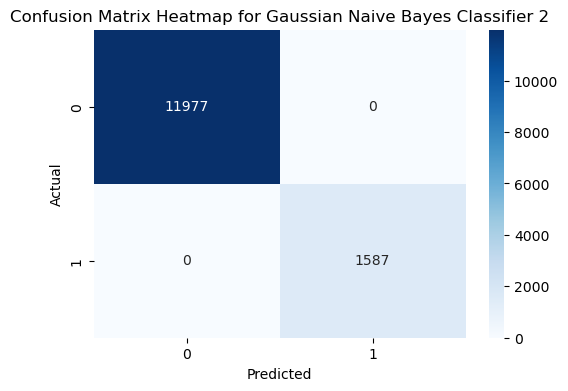

In [68]:
plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix, annot=True, cmap='Blues', fmt='d')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix Heatmap for Gaussian Naive Bayes Classifier 2')
# plt.savefig('confusion_matrix_maxdepth17.png',dpi=200)  # Save the plot as an image
plt.show()

In [69]:
report = classification_report(y_test, y_pred_gnb)
print(report)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     11977
           1       1.00      1.00      1.00      1587

    accuracy                           1.00     13564
   macro avg       1.00      1.00      1.00     13564
weighted avg       1.00      1.00      1.00     13564



# ROC curves

In [70]:
from sklearn.metrics import precision_recall_curve, roc_curve, auc

y_scores = gnb_condition.predict_proba(X_test)
y_true = y_test

# Compute precision-recall curve for class 1
precision1, recall1, _ = precision_recall_curve(y_true, y_scores[:, 1])
# Compute precision-recall curve for class 0
precision0, recall0, _ = precision_recall_curve(y_true, y_scores[:, 0])

# Compute ROC curve for class 1
fpr1, tpr1, _ = roc_curve(y_true, y_scores[:, 1])
roc_auc1 = auc(fpr1, tpr1)
# Compute ROC curve for class 0
fpr0, tpr0, _ = roc_curve(y_true, y_scores[:, 0])
roc_auc0 = auc(fpr0, tpr0)

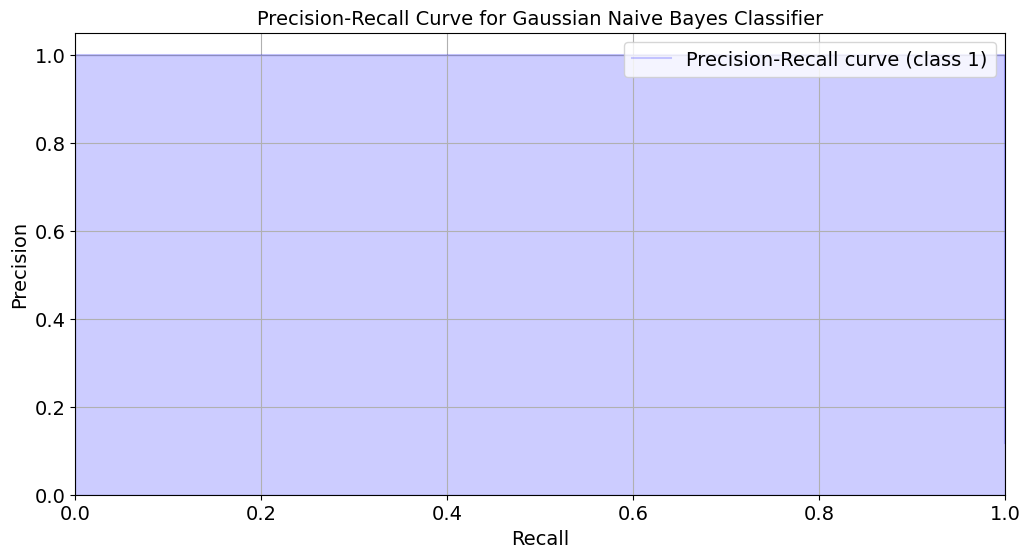

In [71]:
# Plot precision-recall curve
plt.figure(figsize=(12, 6))

plt.step(recall1, precision1, color='b', alpha=0.2, where='post', label='Precision-Recall curve (class 1)')
plt.fill_between(recall1, precision1, step='post', alpha=0.2, color='b')

plt.xlabel('Recall', fontsize=14)
plt.ylabel('Precision', fontsize=14)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.ylim([0.0, 1.05])
plt.xlim([0.0, 1.0])
plt.title('Precision-Recall Curve for Gaussian Naive Bayes Classifier', fontsize=14)
plt.grid(True)
plt.legend(loc="upper right", fontsize=14)
plt.show()

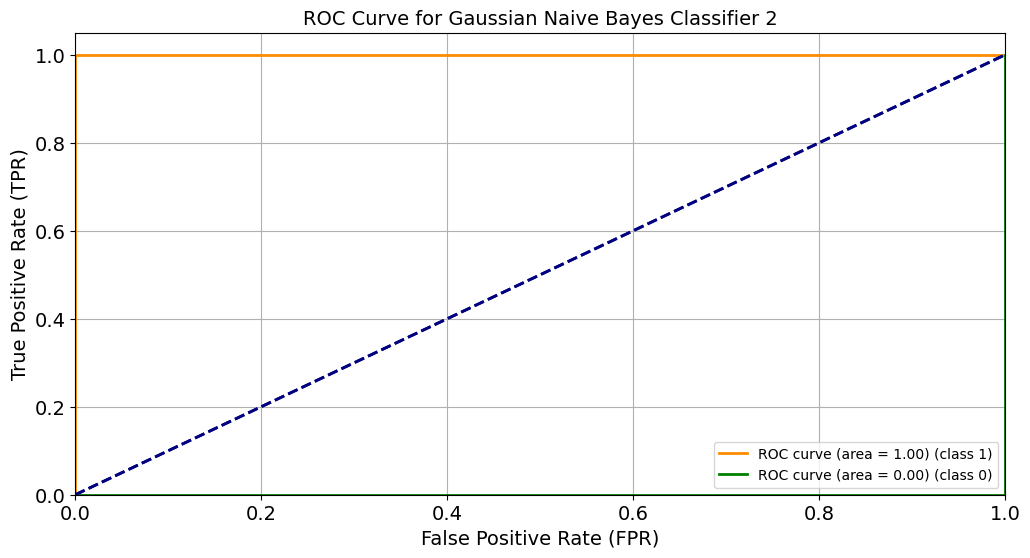

In [72]:
# Plot ROC curves
plt.figure(figsize=(12, 6))

# Plot ROC curve for class 1
plt.plot(fpr1, tpr1, color='darkorange', lw=2, label='ROC curve (area = %0.2f) (class 1)' % roc_auc1)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')

# Plot ROC curve for class 0
plt.plot(fpr0, tpr0, color='green', lw=2, label='ROC curve (area = %0.2f) (class 0)' % roc_auc0)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.xlabel('False Positive Rate (FPR)', fontsize=14)
plt.ylabel('True Positive Rate (TPR)', fontsize=14)
plt.title('ROC Curve for Gaussian Naive Bayes Classifier 2', fontsize=14)
plt.legend(loc="lower right")
plt.grid(True)

plt.show()

# Naive Bayes for Categorical Data using Categorical NB

In [187]:
data = pd.read_csv('bank-full.csv', sep=';')

In [188]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        45211 non-null  int64 
 1   job        45211 non-null  object
 2   marital    45211 non-null  object
 3   education  45211 non-null  object
 4   default    45211 non-null  object
 5   balance    45211 non-null  int64 
 6   housing    45211 non-null  object
 7   loan       45211 non-null  object
 8   contact    45211 non-null  object
 9   day        45211 non-null  int64 
 10  month      45211 non-null  object
 11  duration   45211 non-null  int64 
 12  campaign   45211 non-null  int64 
 13  pdays      45211 non-null  int64 
 14  previous   45211 non-null  int64 
 15  poutcome   45211 non-null  object
 16  y          45211 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.9+ MB


# Preprocessing for Categorical NB

In [189]:
# Create separate DataFrames for equal width and equal frequency discretization
df_equal_width = data.copy()
df_equal_frequency = data.copy()

# Columns with continuous values
continuous_columns = ['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']

# Number of bins for discretization
num_bins = 4

# Equal Width Discretization
for col in continuous_columns:
    df_equal_width[col] = pd.cut(data[col], bins=num_bins, labels=False)

# Equal Frequency Discretization
for col in continuous_columns:
    df_equal_frequency[col] = pd.qcut(data[col], q=num_bins, labels=False, duplicates='drop')

# Encode categorical features
label_encoders = {}
for column in df_equal_width.columns:
    if df_equal_width[column].dtype == 'object' or column in continuous_columns or column == 'Age':
        le = LabelEncoder()
        df_equal_width[column] = le.fit_transform(df_equal_width[column].astype(str))
        df_equal_frequency[column] = le.fit_transform(df_equal_frequency[column].astype(str))
        label_encoders[column] = le

# Preprocessing ends

In [190]:
# Target variable
target = 'y'
df_equal_width[target] = LabelEncoder().fit_transform(df_equal_width[target])
df_equal_frequency[target] = LabelEncoder().fit_transform(df_equal_frequency[target])

# Split the data into training and testing sets
X_train_width, X_test_width, y_train_width, y_test_width = train_test_split(
    df_equal_width.drop(columns=[target]), df_equal_width[target], test_size=0.3, random_state=10, stratify = df_equal_width[target])

X_train_frequency, X_test_frequency, y_train_frequency, y_test_frequency = train_test_split(
    df_equal_frequency.drop(columns=[target]), df_equal_frequency[target], test_size=0.3, random_state=10, stratify = df_equal_width[target])

In [191]:
# Train the Multinomial Naive Bayes model
nb_model_width = CategoricalNB()
nb_model_width.fit(X_train_width, y_train_width)

CategoricalNB()

In [192]:
nb_model_frequency = CategoricalNB()
nb_model_frequency.fit(X_train_frequency, y_train_frequency)

CategoricalNB()

In [193]:
# Predict and evaluate the model for equal width discretized data
y_pred_width = nb_model_width.predict(X_test_width)
print("Equal Width Discretization Results:")
print("Accuracy:", accuracy_score(y_test_width, y_pred_width))
print(classification_report(y_test_width, y_pred_width))

Equal Width Discretization Results:
Accuracy: 0.8852108522559717
              precision    recall  f1-score   support

           0       0.92      0.96      0.94     11977
           1       0.51      0.34      0.41      1587

    accuracy                           0.89     13564
   macro avg       0.72      0.65      0.67     13564
weighted avg       0.87      0.89      0.87     13564



In [194]:
conf_matrix = confusion_matrix(y_test_width, y_pred_width)
print(conf_matrix)

[[11474   503]
 [ 1054   533]]


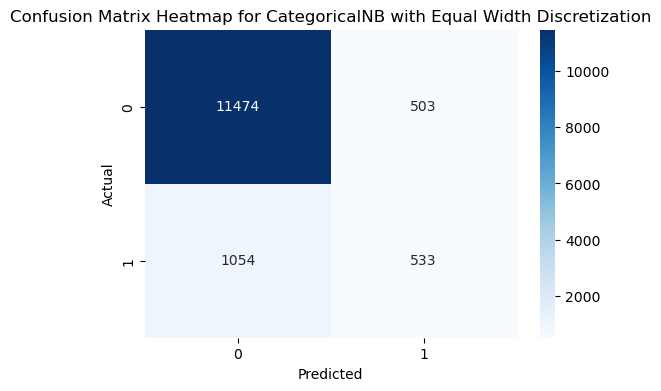

In [195]:
plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix, annot=True, cmap='Blues', fmt='d')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix Heatmap for CategoricalNB with Equal Width Discretization')
# plt.savefig('confusion_matrix_maxdepth17.png',dpi=200)  # Save the plot as an image
plt.show()

In [196]:
# Predict and evaluate the model for equal frequency discretized data
y_pred_frequency = nb_model_frequency.predict(X_test_frequency)
print("Equal Frequency Discretization Results:")
print("Accuracy:", accuracy_score(y_test_frequency, y_pred_frequency))
print(classification_report(y_test_frequency, y_pred_frequency))

Equal Frequency Discretization Results:
Accuracy: 0.8928782070185786
              precision    recall  f1-score   support

           0       0.92      0.96      0.94     11977
           1       0.56      0.39      0.46      1587

    accuracy                           0.89     13564
   macro avg       0.74      0.68      0.70     13564
weighted avg       0.88      0.89      0.88     13564



In [197]:
conf_matrix = confusion_matrix(y_test_frequency, y_pred_frequency)
print(conf_matrix)

[[11485   492]
 [  961   626]]


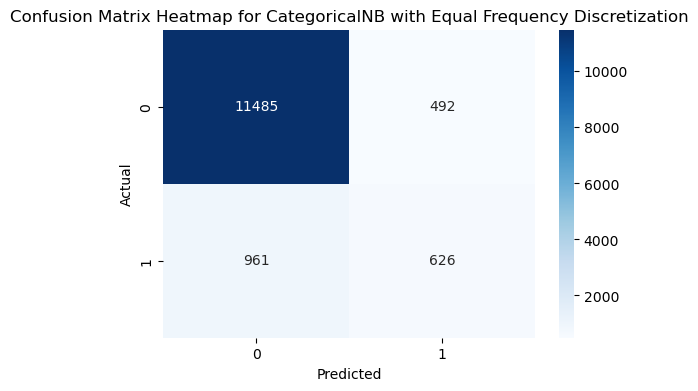

In [198]:
plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix, annot=True, cmap='Blues', fmt='d')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix Heatmap for CategoricalNB with Equal Frequency Discretization')
# plt.savefig('confusion_matrix_maxdepth17.png',dpi=200)  # Save the plot as an image
plt.show()

# CURVES FOR BOTH

## Equal Frequency

In [202]:
from sklearn.metrics import precision_recall_curve, roc_curve, auc

y_scores = nb_model_frequency.predict_proba(X_test_frequency)
y_true = y_test_frequency

# Compute precision-recall curve for class 1
precision1, recall1, _ = precision_recall_curve(y_true, y_scores[:, 1])
# Compute precision-recall curve for class 0
precision0, recall0, _ = precision_recall_curve(y_true, y_scores[:, 0])

# Compute ROC curve for class 1
fpr1, tpr1, _ = roc_curve(y_true, y_scores[:, 1])
roc_auc1 = auc(fpr1, tpr1)
# Compute ROC curve for class 0
fpr0, tpr0, _ = roc_curve(y_true, y_scores[:, 0])
roc_auc0 = auc(fpr0, tpr0)

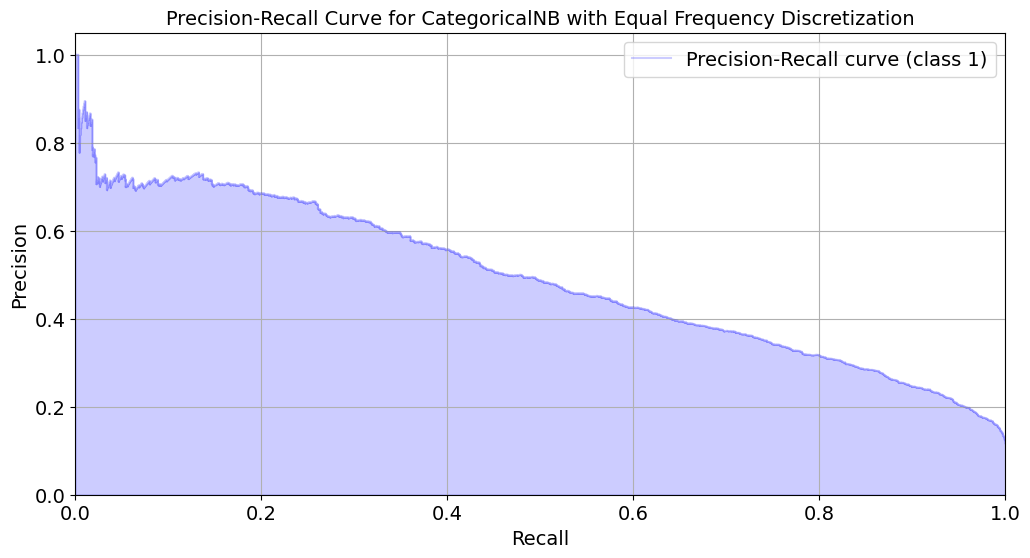

In [203]:
# Plot precision-recall curve
plt.figure(figsize=(12, 6))

plt.step(recall1, precision1, color='b', alpha=0.2, where='post', label='Precision-Recall curve (class 1)')
plt.fill_between(recall1, precision1, step='post', alpha=0.2, color='b')

plt.xlabel('Recall', fontsize=14)
plt.ylabel('Precision', fontsize=14)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.ylim([0.0, 1.05])
plt.xlim([0.0, 1.0])
plt.title('Precision-Recall Curve for CategoricalNB with Equal Frequency Discretization', fontsize=14)
plt.grid(True)
plt.legend(loc="upper right", fontsize=14)
plt.show()

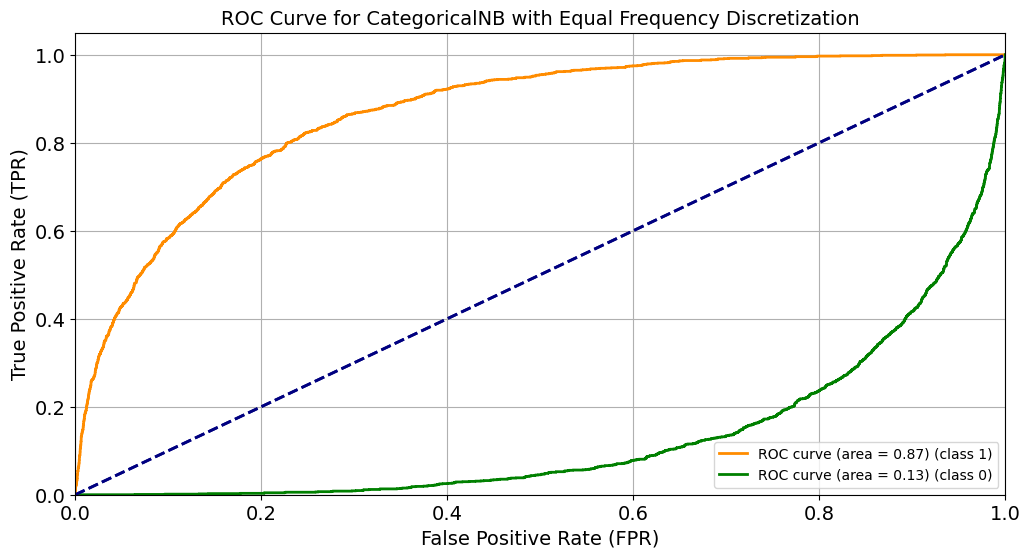

In [204]:
# Plot ROC curves
plt.figure(figsize=(12, 6))

# Plot ROC curve for class 1
plt.plot(fpr1, tpr1, color='darkorange', lw=2, label='ROC curve (area = %0.2f) (class 1)' % roc_auc1)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')

# Plot ROC curve for class 0
plt.plot(fpr0, tpr0, color='green', lw=2, label='ROC curve (area = %0.2f) (class 0)' % roc_auc0)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.xlabel('False Positive Rate (FPR)', fontsize=14)
plt.ylabel('True Positive Rate (TPR)', fontsize=14)
plt.title('ROC Curve for CategoricalNB with Equal Frequency Discretization', fontsize=14)
plt.legend(loc="lower right")
plt.grid(True)

plt.show()

## Equal Width

In [199]:
from sklearn.metrics import precision_recall_curve, roc_curve, auc

y_scores = nb_model_width.predict_proba(X_test_width)
y_true = y_test_width

# Compute precision-recall curve for class 1
precision1, recall1, _ = precision_recall_curve(y_true, y_scores[:, 1])
# Compute precision-recall curve for class 0
precision0, recall0, _ = precision_recall_curve(y_true, y_scores[:, 0])

# Compute ROC curve for class 1
fpr1, tpr1, _ = roc_curve(y_true, y_scores[:, 1])
roc_auc1 = auc(fpr1, tpr1)
# Compute ROC curve for class 0
fpr0, tpr0, _ = roc_curve(y_true, y_scores[:, 0])
roc_auc0 = auc(fpr0, tpr0)

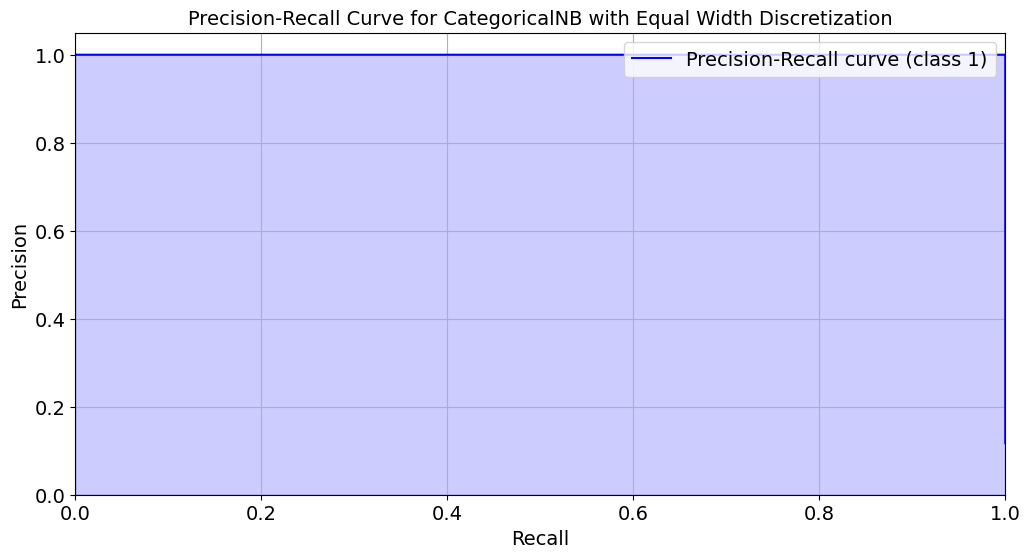

In [542]:
# Plot precision-recall curve
plt.figure(figsize=(12, 6))

plt.step(recall1, precision1, color='b', where='post', label='Precision-Recall curve (class 1)')
plt.fill_between(recall1, precision1, step='post', alpha=0.2, color='b')

plt.xlabel('Recall', fontsize=14)
plt.ylabel('Precision', fontsize=14)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.ylim([0.0, 1.05])
plt.xlim([0.0, 1.0])
plt.title('Precision-Recall Curve for CategoricalNB with Equal Width Discretization', fontsize=14)
plt.grid(True)
plt.legend(loc="upper right", fontsize=14)
plt.show()

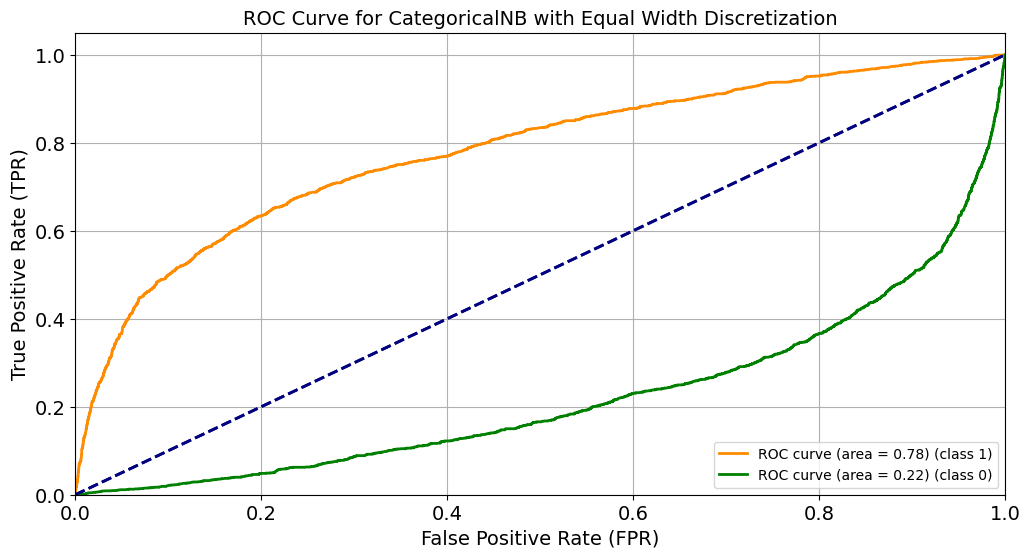

In [201]:
# Plot ROC curves
plt.figure(figsize=(12, 6))

# Plot ROC curve for class 1
plt.plot(fpr1, tpr1, color='darkorange', lw=2, label='ROC curve (area = %0.2f) (class 1)' % roc_auc1)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')

# Plot ROC curve for class 0
plt.plot(fpr0, tpr0, color='green', lw=2, label='ROC curve (area = %0.2f) (class 0)' % roc_auc0)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.xlabel('False Positive Rate (FPR)', fontsize=14)
plt.ylabel('True Positive Rate (TPR)', fontsize=14)
plt.title('ROC Curve for CategoricalNB with Equal Width Discretization', fontsize=14)
plt.legend(loc="lower right")
plt.grid(True)

plt.show()

# TEST: CONDITIONAL INDEPENDENCE

In [205]:
# Create separate DataFrames for equal width and equal frequency discretization
df_equal_width = data_reduced.copy()
df_equal_frequency = data_reduced.copy()

# Columns with continuous values (excluding 'age' since it has custom bins and labels)
continuous_columns = ['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']

# Number of bins for discretization
num_bins = 4

# Equal Width Discretization
for col in continuous_columns:
    df_equal_width[col] = pd.cut(data[col], bins=num_bins, labels=False)

# Equal Frequency Discretization
for col in continuous_columns:
    df_equal_frequency[col] = pd.qcut(data[col], q=num_bins, labels=False, duplicates='drop')

# Encode categorical features
label_encoders = {}
for column in df_equal_width.columns:
    if df_equal_width[column].dtype == 'object' or column in continuous_columns or column == 'Age':
        le = LabelEncoder()
        df_equal_width[column] = le.fit_transform(df_equal_width[column].astype(str))
        df_equal_frequency[column] = le.fit_transform(df_equal_frequency[column].astype(str))
        label_encoders[column] = le

In [206]:
# Split the data into training and testing sets
X_train_width, X_test_width, y_train_width, y_test_width = train_test_split(
    df_equal_width, y, test_size=0.3, random_state=10, stratify = y)

X_train_frequency, X_test_frequency, y_train_frequency, y_test_frequency = train_test_split(
    df_equal_frequency, y, test_size=0.3, random_state=10, stratify = y)

In [207]:
# Train the Multinomial Naive Bayes model
nb_model_width = CategoricalNB()
nb_model_width.fit(X_train_width, y_train_width)

CategoricalNB()

In [208]:
nb_model_frequency = CategoricalNB()
nb_model_frequency.fit(X_train_frequency, y_train_frequency)

CategoricalNB()

In [209]:
# Predict and evaluate the model for equal width discretized data
y_pred_width = nb_model_width.predict(X_test_width)
print("Equal Width Discretization Results:")
print("Accuracy:", accuracy_score(y_test_width, y_pred_width))
print(classification_report(y_test_width, y_pred_width))

Equal Width Discretization Results:
Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     11977
           1       1.00      1.00      1.00      1587

    accuracy                           1.00     13564
   macro avg       1.00      1.00      1.00     13564
weighted avg       1.00      1.00      1.00     13564



In [210]:
conf_matrix = confusion_matrix(y_test_width, y_pred_width)
print(conf_matrix)

[[11977     0]
 [    0  1587]]


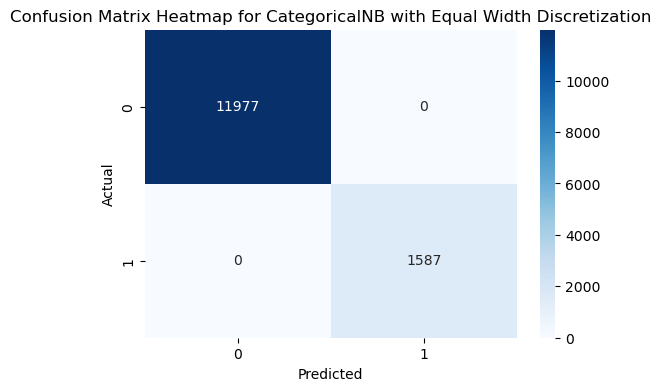

In [211]:
plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix, annot=True, cmap='Blues', fmt='d')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix Heatmap for CategoricalNB with Equal Width Discretization')
# plt.savefig('confusion_matrix_maxdepth17.png',dpi=200)  # Save the plot as an image
plt.show()

In [213]:
# Predict and evaluate the model for equal frequency discretized data
y_pred_frequency = nb_model_frequency.predict(X_test_frequency)
print("Equal Frequency Discretization Results:")
print("Accuracy:", accuracy_score(y_test_frequency, y_pred_frequency))
print(classification_report(y_test_frequency, y_pred_frequency))

Equal Frequency Discretization Results:
Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     11977
           1       1.00      1.00      1.00      1587

    accuracy                           1.00     13564
   macro avg       1.00      1.00      1.00     13564
weighted avg       1.00      1.00      1.00     13564



In [214]:
conf_matrix = confusion_matrix(y_test_frequency, y_pred_frequency)
print(conf_matrix)

[[11977     0]
 [    0  1587]]


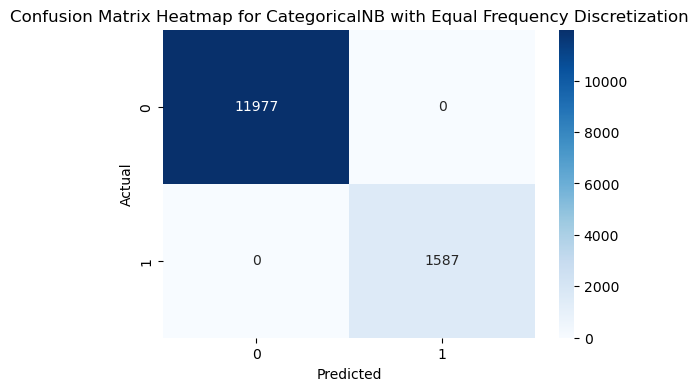

In [215]:
plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix, annot=True, cmap='Blues', fmt='d')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix Heatmap for CategoricalNB with Equal Frequency Discretization')
# plt.savefig('confusion_matrix_maxdepth17.png',dpi=200)  # Save the plot as an image
plt.show()

# CURVES FOR BOTH

## Equal Frequency

In [216]:
from sklearn.metrics import precision_recall_curve, roc_curve, auc

y_scores = nb_model_frequency.predict_proba(X_test_frequency)
y_true = y_test_frequency

# Compute precision-recall curve for class 1
precision1, recall1, _ = precision_recall_curve(y_true, y_scores[:, 1])
# Compute precision-recall curve for class 0
precision0, recall0, _ = precision_recall_curve(y_true, y_scores[:, 0])

# Compute ROC curve for class 1
fpr1, tpr1, _ = roc_curve(y_true, y_scores[:, 1])
roc_auc1 = auc(fpr1, tpr1)
# Compute ROC curve for class 0
fpr0, tpr0, _ = roc_curve(y_true, y_scores[:, 0])
roc_auc0 = auc(fpr0, tpr0)

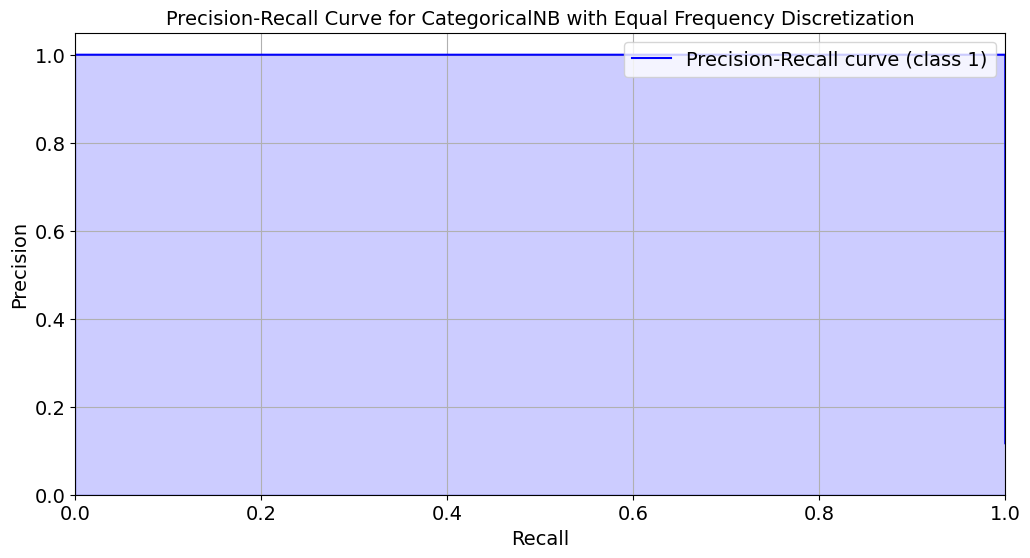

In [541]:
# Plot precision-recall curve
plt.figure(figsize=(12, 6))

plt.step(recall1, precision1, color='b', where='post', label='Precision-Recall curve (class 1)')
plt.fill_between(recall1, precision1, step='post', alpha=0.2, color='b')

plt.xlabel('Recall', fontsize=14)
plt.ylabel('Precision', fontsize=14)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.ylim([0.0, 1.05])
plt.xlim([0.0, 1.0])
plt.title('Precision-Recall Curve for CategoricalNB with Equal Frequency Discretization', fontsize=14)
plt.grid(True)
plt.legend(loc="upper right", fontsize=14)
plt.show()

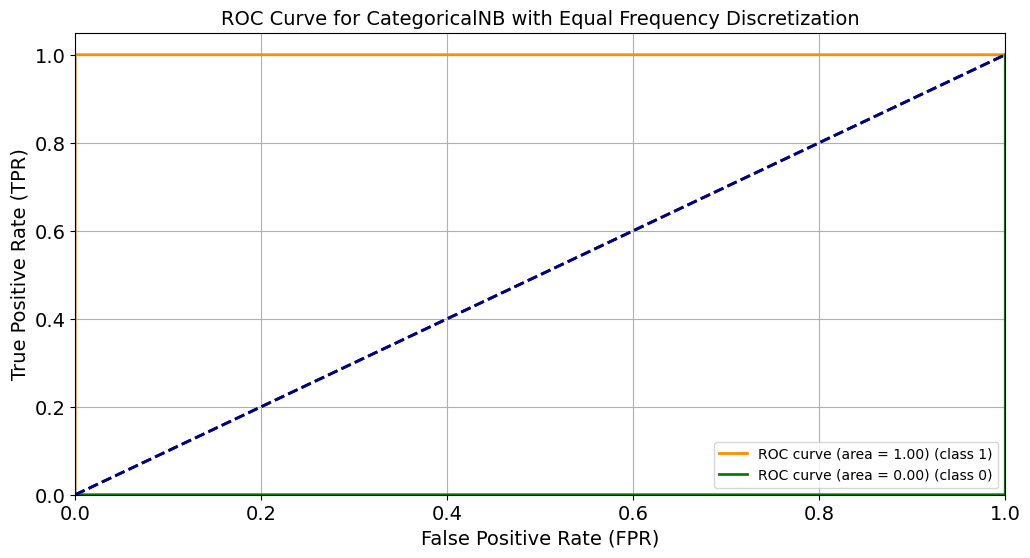

In [218]:
# Plot ROC curves
plt.figure(figsize=(12, 6))

# Plot ROC curve for class 1
plt.plot(fpr1, tpr1, color='darkorange', lw=2, label='ROC curve (area = %0.2f) (class 1)' % roc_auc1)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')

# Plot ROC curve for class 0
plt.plot(fpr0, tpr0, color='green', lw=2, label='ROC curve (area = %0.2f) (class 0)' % roc_auc0)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.xlabel('False Positive Rate (FPR)', fontsize=14)
plt.ylabel('True Positive Rate (TPR)', fontsize=14)
plt.title('ROC Curve for CategoricalNB with Equal Frequency Discretization', fontsize=14)
plt.legend(loc="lower right")
plt.grid(True)

plt.show()

## Equal Width

In [219]:
from sklearn.metrics import precision_recall_curve, roc_curve, auc

y_scores = nb_model_width.predict_proba(X_test_width)
y_true = y_test_width

# Compute precision-recall curve for class 1
precision1, recall1, _ = precision_recall_curve(y_true, y_scores[:, 1])
# Compute precision-recall curve for class 0
precision0, recall0, _ = precision_recall_curve(y_true, y_scores[:, 0])

# Compute ROC curve for class 1
fpr1, tpr1, _ = roc_curve(y_true, y_scores[:, 1])
roc_auc1 = auc(fpr1, tpr1)
# Compute ROC curve for class 0
fpr0, tpr0, _ = roc_curve(y_true, y_scores[:, 0])
roc_auc0 = auc(fpr0, tpr0)

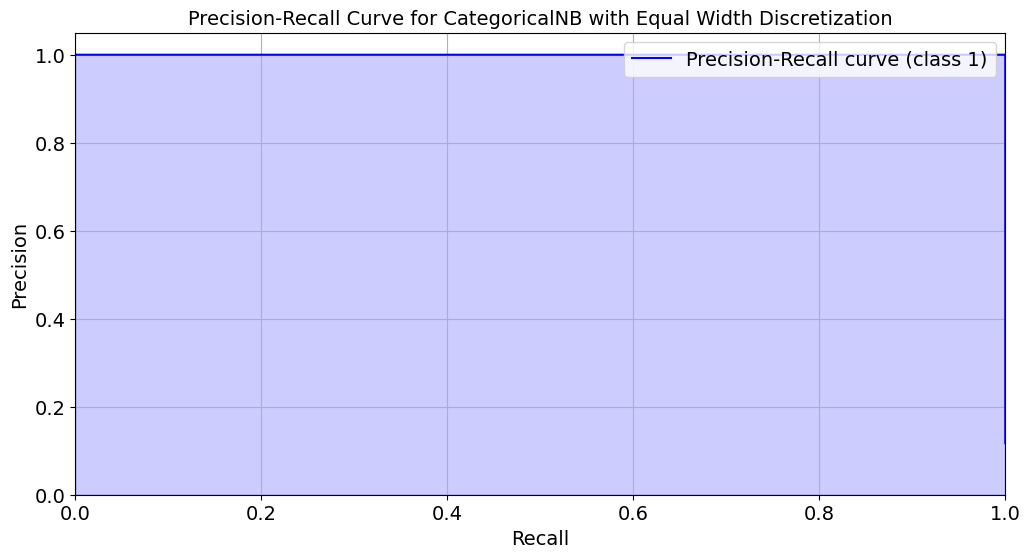

In [540]:
# Plot precision-recall curve
plt.figure(figsize=(12, 6))

plt.step(recall1, precision1, color='b', where='post', label='Precision-Recall curve (class 1)')
plt.fill_between(recall1, precision1, step='post', alpha=0.2, color='b')

plt.xlabel('Recall', fontsize=14)
plt.ylabel('Precision', fontsize=14)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.ylim([0.0, 1.05])
plt.xlim([0.0, 1.0])
plt.title('Precision-Recall Curve for CategoricalNB with Equal Width Discretization', fontsize=14)
plt.grid(True)
plt.legend(loc="upper right", fontsize=14)
plt.show()

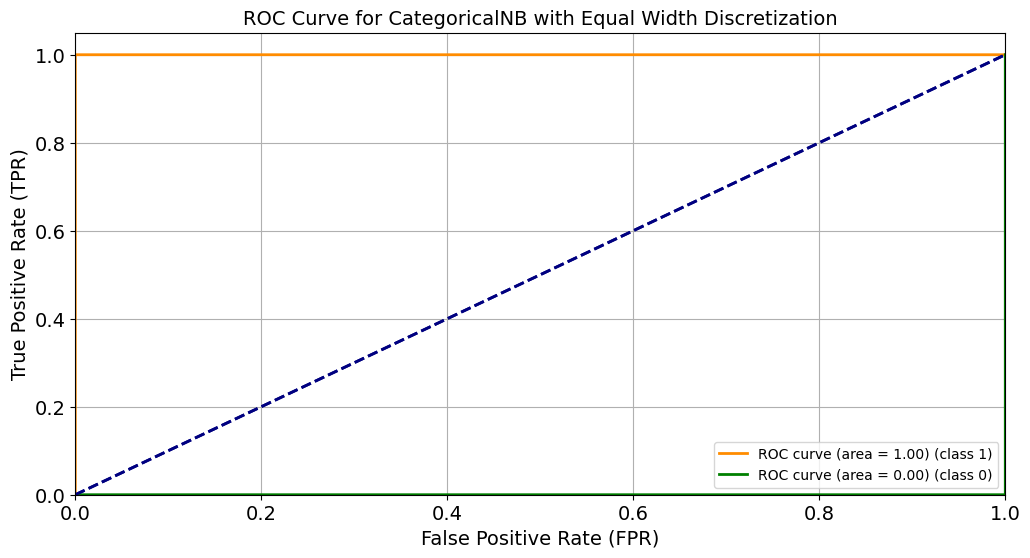

In [221]:
# Plot ROC curves
plt.figure(figsize=(12, 6))

# Plot ROC curve for class 1
plt.plot(fpr1, tpr1, color='darkorange', lw=2, label='ROC curve (area = %0.2f) (class 1)' % roc_auc1)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')

# Plot ROC curve for class 0
plt.plot(fpr0, tpr0, color='green', lw=2, label='ROC curve (area = %0.2f) (class 0)' % roc_auc0)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.xlabel('False Positive Rate (FPR)', fontsize=14)
plt.ylabel('True Positive Rate (TPR)', fontsize=14)
plt.title('ROC Curve for CategoricalNB with Equal Width Discretization', fontsize=14)
plt.legend(loc="lower right")
plt.grid(True)

plt.show()

# Hybrid Approach

In [549]:
data = pd.read_csv('bank-full.csv', sep=';')

In [550]:

numerical_columns = ['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']

# Standardize the log-transformed numerical features
scaler = StandardScaler()
data[numerical_columns] = scaler.fit_transform(data[numerical_columns])

In [551]:
# Define which columns are continuous and which are discrete
continuous_columns = ['age', 'day', 'duration', 'campaign', 'pdays', 'previous']
discrete_columns = ['job', 'marital', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome']

# Encode categorical features for discrete columns
label_encoders = {}
for column in discrete_columns:
    le = LabelEncoder()
    data[column] = le.fit_transform(data[column].astype(str))
    label_encoders[column] = le

# Target variable
target = 'y'
data[target] = LabelEncoder().fit_transform(data[target])

In [552]:
# Splitting the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    data.drop(columns=[target]), data[target], test_size=0.3, random_state=10, stratify = data[target])

# Split features into continuous and discrete
X_train_continuous = X_train[continuous_columns]
X_train_discrete = X_train[discrete_columns]
X_test_continuous = X_test[continuous_columns]
X_test_discrete = X_test[discrete_columns]


In [553]:
# Train Gaussian Naive Bayes on continuous features
gnb = GaussianNB()
gnb.fit(X_train_continuous, y_train)


GaussianNB()

In [554]:
# Train Categorical Naive Bayes on discrete features
mnb = CategoricalNB()
mnb.fit(X_train_discrete, y_train)

CategoricalNB()

In [555]:

# Get log probabilities from both models
gnb_log_proba = gnb.predict_log_proba(X_test_continuous)
mnb_log_proba = mnb.predict_log_proba(X_test_discrete)

# Combine log probabilities (by summing them)
combined_log_proba = gnb_log_proba + mnb_log_proba

# Get the final predictions by choosing the class with the highest combined log probability
y_pred = np.argmax(combined_log_proba, axis=1)

# Evaluate the hybrid model
print("Hybrid Naive Bayes Results:")
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Hybrid Naive Bayes Results:
Accuracy: 0.896711884399882
              precision    recall  f1-score   support

           0       0.91      0.98      0.94     11977
           1       0.62      0.31      0.41      1587

    accuracy                           0.90     13564
   macro avg       0.77      0.64      0.68     13564
weighted avg       0.88      0.90      0.88     13564



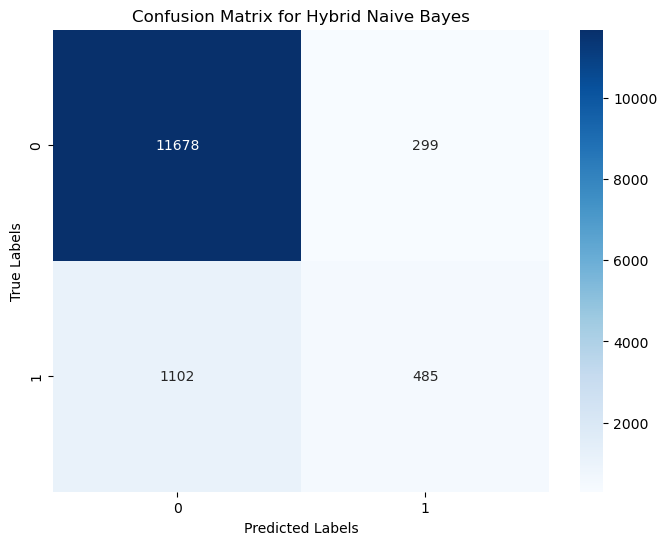

In [560]:
# Confusion Matrix Heatmap
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix for Hybrid Naive Bayes')
plt.show()

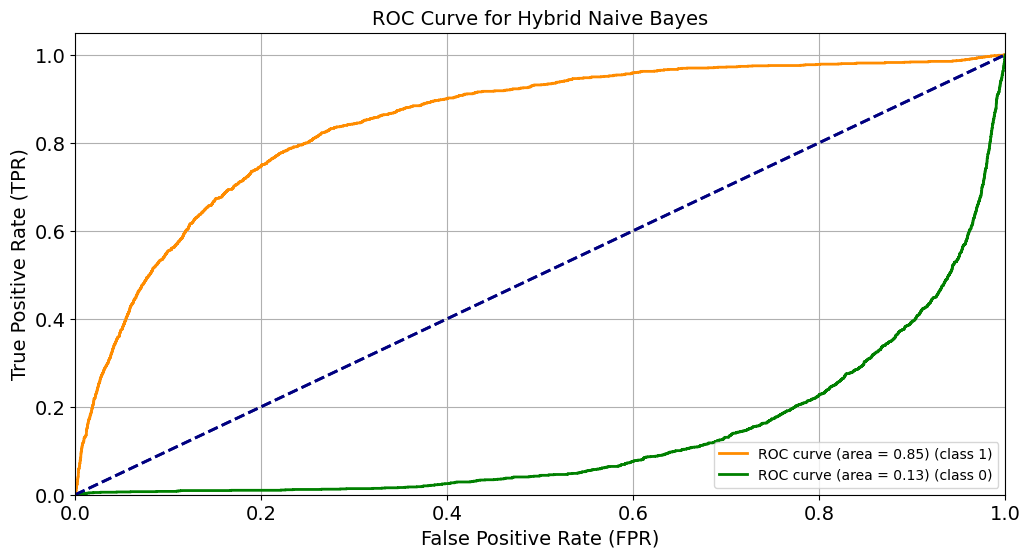

In [544]:

# Compute ROC curve for class 1
fpr1, tpr1, _ = roc_curve(y_test, combined_log_proba[:, 1])
roc_auc1 = auc(fpr1, tpr1)
# Compute ROC curve for class 0
fpr0, tpr0, _ = roc_curve(y_test, combined_log_proba[:, 0])
roc_auc0 = auc(fpr0, tpr0)


# Plot ROC curves
plt.figure(figsize=(12, 6))

# Plot ROC curve for class 1
plt.plot(fpr1, tpr1, color='darkorange', lw=2, label='ROC curve (area = %0.2f) (class 1)' % roc_auc1)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')

# Plot ROC curve for class 0
plt.plot(fpr0, tpr0, color='green', lw=2, label='ROC curve (area = %0.2f) (class 0)' % roc_auc0)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.xlabel('False Positive Rate (FPR)', fontsize=14)
plt.ylabel('True Positive Rate (TPR)', fontsize=14)
plt.title('ROC Curve for Hybrid Naive Bayes', fontsize=14)
plt.legend(loc="lower right")
plt.grid(True)

plt.show()

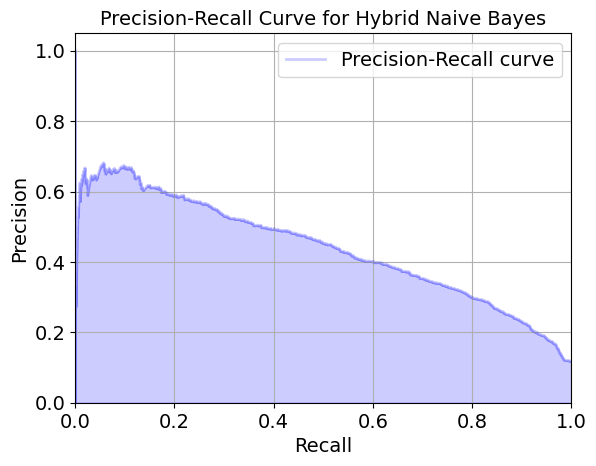

In [545]:
# Precision-Recall Curve
precision, recall, _ = precision_recall_curve(y_test, combined_log_proba[:, 1])

plt.plot(recall, precision, color='blue', alpha=0.2, lw=2, label='Precision-Recall curve')
plt.fill_between(recall, precision, step='post', alpha=0.2, color='b')
plt.xlabel('Recall', fontsize=14)
plt.ylabel('Precision', fontsize=14)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.ylim([0.0, 1.05])
plt.xlim([0.0, 1.0])
plt.title('Precision-Recall Curve for Hybrid Naive Bayes', fontsize=14)
plt.grid(True)
plt.legend(loc="upper right", fontsize=14)
plt.show()